In [11]:
import gymnasium as gym
env = gym.make('Taxi-v3', render_mode='rgb_array')

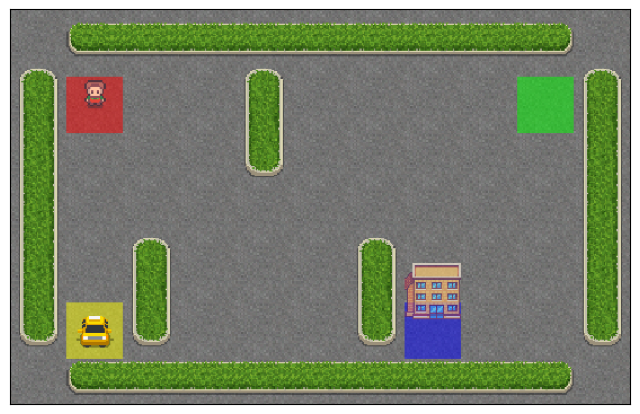

In [12]:
import matplotlib.pyplot as plt
initial_state, _ = env.reset()
img = env.render()
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.set_xticks([])
ax.set_yticks([]);

In [13]:
n_states = env.observation_space.n
n_actions = env.action_space.n
print(n_states)
print(n_actions)

500
6


In [14]:
n_episodes = 5000

In [15]:
for episode in range(n_episodes):
   state, _ = env.reset()
   done = False
   total_reward = 0
   steps = 0
   while not done:
       action = env.action_space.sample()
       next_state, reward, terminated, truncated, _ = env.step(action)
       done = terminated or truncated
       total_reward += reward
       steps += 1
       state = next_state
   if episode % 1000 == 0:
       print(f"Episode {episode}, Total Reward: {total_reward}, Steps: {steps}")

Episode 0, Total Reward: -821, Steps: 200
Episode 1000, Total Reward: -794, Steps: 200
Episode 2000, Total Reward: -767, Steps: 200
Episode 3000, Total Reward: -794, Steps: 200
Episode 4000, Total Reward: -785, Steps: 200


In [16]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
n_episodes = 1
frames = []
for episode in range(n_episodes):
   state, _ = env.reset()
   img = env.render()
   frames.append(img)
   done = False
   total_reward = 0
   steps = 0
   while not done:
       action = env.action_space.sample()
       next_state, reward, terminated, truncated, _ = env.step(action)
       done = terminated or truncated

       img = env.render()
       frames.append(img)
       total_reward += reward
       steps += 1
       state = next_state

In [18]:
>>> len(frames)

201

In [19]:
pip install moviepy

In [20]:
from moviepy.editor import ImageSequenceClip
def create_gif(frames: list, filename, fps=5):
   clip = ImageSequenceClip(frames, fps=fps)
   clip.write_gif(filename, fps=fps)
create_gif(frames, "animation.gif", fps=25)

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  return datetime.utcnow().replace(tzinfo=utc)

  from scipy.ndimage.filters import sobel

  if event.key is 'enter':



MoviePy - Building file animation.gif with imageio.


Implementing SARSA IN PYTHON

In [21]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
env = gym.make("Taxi-v3", render_mode="rgb_array")

In [22]:

n_states = env.observation_space.n
n_actions = env.action_space.n
Q_table = np.zeros((n_states, n_actions))

In [23]:
>>> Q_table.shape

(500, 6)

In [24]:
alpha = 0.1  # Learning rate
gamma = 0.99  # Discount factor
epsilon = 0.1  # Exploration rate for epsilon-greedy policy
n_episodes = 20000

In [25]:
episode_rewards = []
episode_lengths = []

In [26]:
def epsilon_greedy(state, epsilon):
   if np.random.random() < epsilon:
       # Take random action - explore
       return env.action_space.sample()
   else:
       # Take action with the highest Q-value - exploit
       return np.argmax(Q_table[state])

In [30]:
# SARSA training loop
for episode in range(n_episodes):
   state, _ = env.reset()
   action = epsilon_greedy(state, epsilon)
   done = False
   total_reward = 0
   steps = 0
   while not done:
       next_state, reward, terminated, truncated, _ = env.step(action)
       done = terminated or truncated
       next_action = epsilon_greedy(next_state, epsilon)
       Q_table[state, action] += alpha * (
           reward + gamma * Q_table[next_state, next_action] - Q_table[state, action]
       )
       state = next_state
       action = next_action
       total_reward += reward
       steps += 1
   episode_rewards.append(total_reward)
   episode_lengths.append(steps)
   if episode % 2000 == 0:
       avg_reward = np.mean(episode_rewards[-1000:])
       avg_length = np.mean(episode_lengths[-1000:])
       print(f"Episode {episode}, Avg Reward: {avg_reward:.2f}, Avg Length: {avg_length:.2f}")

Episode 0, Avg Reward: -632.00, Avg Length: 200.00
Episode 2000, Avg Reward: -4.35, Avg Length: 19.19
Episode 4000, Avg Reward: 1.96, Avg Length: 14.99
Episode 6000, Avg Reward: 1.84, Avg Length: 14.77
Episode 8000, Avg Reward: 1.97, Avg Length: 14.90
Episode 10000, Avg Reward: 2.24, Avg Length: 14.79
Episode 12000, Avg Reward: 2.61, Avg Length: 14.78
Episode 14000, Avg Reward: 2.43, Avg Length: 14.70
Episode 16000, Avg Reward: 2.70, Avg Length: 14.61
Episode 18000, Avg Reward: 2.51, Avg Length: 14.61


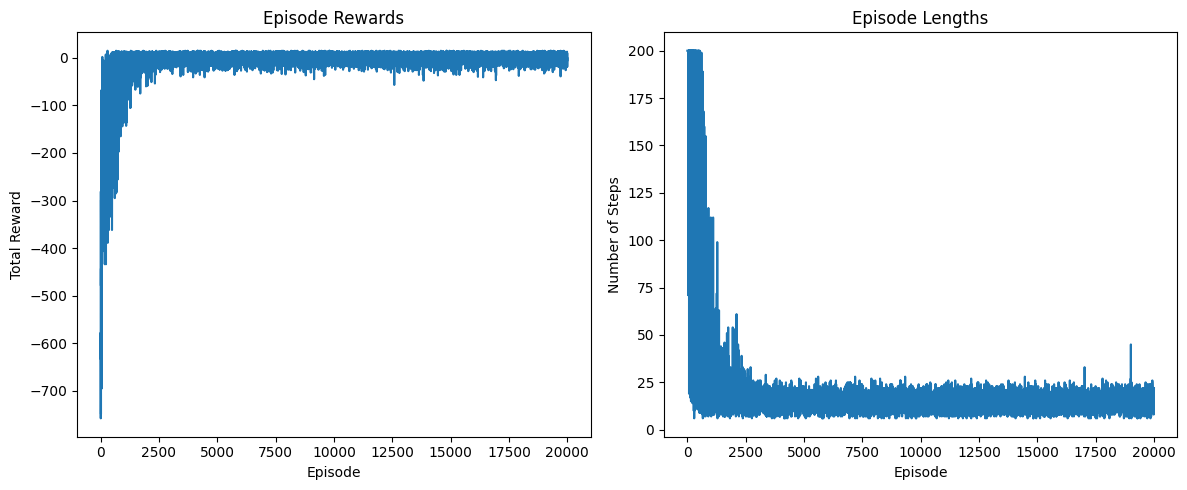

In [31]:
# Plot the learning curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(episode_rewards)
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.subplot(1, 2, 2)
plt.plot(episode_lengths)
plt.title("Episode Lengths")
plt.xlabel("Episode")
plt.ylabel("Number of Steps")
plt.tight_layout()
plt.show()